# Day 2

## Pandas

In [4]:
import pandas as pd
import numpy as np

data= {"Energy sourse":["solar","wind","Hydropower","Geothermal","Biomass","Nuclear"],
        "Energy Consumption(MWH)":[1200,np.nan ,2900,np.nan, 25000,3200],
       "cost(Million $)":[200,400,np.nan,150,250,np.nan]
}

energy_df=pd.DataFrame(data)
print("original Energy DAta with Missing VAlues:")
print(energy_df)

original Energy DAta with Missing VAlues:
  Energy sourse  Energy Consumption(MWH)  cost(Million $)
0         solar                   1200.0            200.0
1          wind                      NaN            400.0
2    Hydropower                   2900.0              NaN
3    Geothermal                      NaN            150.0
4       Biomass                  25000.0            250.0
5       Nuclear                   3200.0              NaN


In [5]:
energy_df

,Energy sourse,Energy Consumption(MWH),cost(Million $)
0,solar,1200.0,200.0
1,wind,NaN,400.0
2,Hydropower,2900.0,NaN
3,Geothermal,NaN,150.0
4,Biomass,25000.0,250.0
5,Nuclear,3200.0,NaN


In [6]:
energy_df.head()

,Energy sourse,Energy Consumption(MWH),cost(Million $)
0,solar,1200.0,200.0
1,wind,NaN,400.0
2,Hydropower,2900.0,NaN
3,Geothermal,NaN,150.0
4,Biomass,25000.0,250.0


In [7]:
energy_df.tail()

,Energy sourse,Energy Consumption(MWH),cost(Million $)
1,wind,NaN,400.0
2,Hydropower,2900.0,NaN
3,Geothermal,NaN,150.0
4,Biomass,25000.0,250.0
5,Nuclear,3200.0,NaN


In [8]:
energy_df.head(2)

,Energy sourse,Energy Consumption(MWH),cost(Million $)
0,solar,1200.0,200.0
1,wind,NaN,400.0


In [9]:
energy_df.columns

Index(['Energy sourse', 'Energy Consumption(MWH)', 'cost(Million $)'], dtype='object')

In [10]:
energy_df.axes

[RangeIndex(start=0, stop=6, step=1),
 Index(['Energy sourse', 'Energy Consumption(MWH)', 'cost(Million $)'], dtype='object')]

In [11]:
energy_df.shape

(6, 3)

In [12]:
energy_df.isnull().sum()

Energy sourse              0
Energy Consumption(MWH)    2
cost(Million $)            2
dtype: int64

In [13]:
energy_df.isnull().sum().sum()

4

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
# Remove rows with any missing values using dropna()
cleaned_df=energy_df.dropna()
print("cleaned Energy Data Data After removing rows and columns:")
print(cleaned_df)

cleaned Energy Data Data After removing rows and columns:
  Energy sourse  Energy Consumption(MWH)  cost(Million $)
0         solar                   1200.0            200.0
4       Biomass                  25000.0            250.0


In [16]:
energy_df["Energy Consumption(MWH)"].fillna (energy_df["Energy Consumption(MWH)"].mean(), inplace=True)
energy_df["cost(Million $)"].fillna(energy_df["cost(Million $)"].mean(),inplace=True)
print("\n Data After Imputing Missing values with Mean:" )
print(energy_df)


 Data After Imputing Missing values with Mean:
  Energy sourse  Energy Consumption(MWH)  cost(Million $)
0         solar                   1200.0            200.0
1          wind                   8075.0            400.0
2    Hydropower                   2900.0            250.0
3    Geothermal                   8075.0            150.0
4       Biomass                  25000.0            250.0
5       Nuclear                   3200.0            250.0


In [17]:
forward_filled_df=energy_df.fillna(method="ffill")
print("Data After Forward  Filling:")
print(forward_filled_df)

Data After Forward  Filling:
  Energy sourse  Energy Consumption(MWH)  cost(Million $)
0         solar                   1200.0            200.0
1          wind                   8075.0            400.0
2    Hydropower                   2900.0            250.0
3    Geothermal                   8075.0            150.0
4       Biomass                  25000.0            250.0
5       Nuclear                   3200.0            250.0


In [18]:
from sklearn.preprocessing  import MinMaxScaler
scaler =MinMaxScaler()
energy_df[["Energy Consumption(MWH)","cost(Million $)"]]=scaler.fit_transform(energy_df[["Energy Consumption(MWH)","cost(Million $)"]])

print("Data After Normalizing(MIn -Max Scaling):")
print(energy_df)

Data After Normalizing(MIn -Max Scaling):
  Energy sourse  Energy Consumption(MWH)  cost(Million $)
0         solar                 0.000000              0.2
1          wind                 0.288866              1.0
2    Hydropower                 0.071429              0.4
3    Geothermal                 0.288866              0.0
4       Biomass                 1.000000              0.4
5       Nuclear                 0.084034              0.4


In [19]:
energy_df.isnull().sum()

Energy sourse              0
Energy Consumption(MWH)    0
cost(Million $)            0
dtype: int64

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
energy_df[["Energy Consumption(MWH)","cost(Million $)"]]=scaler.fit_transform(energy_df[["Energy Consumption(MWH)","cost(Million $)"]])
print("Data After Normalizing(Standardization):")
print(energy_df)

Data After Normalizing(Standardization):
  Energy sourse  Energy Consumption(MWH)  cost(Million $)
0         solar                -0.859076    -6.546537e-01
1          wind                 0.000000     1.963961e+00
2    Hydropower                -0.646650     1.817029e-16
3    Geothermal                 0.000000    -1.309307e+00
4       Biomass                 2.114888     1.817029e-16
5       Nuclear                -0.609163     1.817029e-16


In [21]:
energy_encoded_df=pd.get_dummies(energy_df,columns=["Energy sourse"],drop_first=True)
print("Data After Encoding Categorical Variables:")
print(energy_encoded_df)

Data After Encoding Categorical Variables:
   Energy Consumption(MWH)  cost(Million $)  Energy sourse_Geothermal  \
0                -0.859076    -6.546537e-01                     False   
1                 0.000000     1.963961e+00                     False   
2                -0.646650     1.817029e-16                     False   
3                 0.000000    -1.309307e+00                      True   
4                 2.114888     1.817029e-16                     False   
5                -0.609163     1.817029e-16                     False   

   Energy sourse_Hydropower  Energy sourse_Nuclear  Energy sourse_solar  \
0                     False                  False                 True   
1                     False                  False                False   
2                      True                  False                False   
3                     False                  False                False   
4                     False                  False                Fals

In [22]:
energy_encoded_df

,Energy Consumption(MWH),cost(Million $),Energy sourse_Geothermal,Energy sourse_Hydropower,Energy sourse_Nuclear,Energy sourse_solar,Energy sourse_wind
0,-0.859076,-6.546537e-01,False,False,False,True,False
1,0.000000,1.963961e+00,False,False,False,False,True
2,-0.646650,1.817029e-16,False,True,False,False,False
3,0.000000,-1.309307e+00,True,False,False,False,False
4,2.114888,1.817029e-16,False,False,False,False,False
5,-0.609163,1.817029e-16,False,False,True,False,False


In [23]:
energy_encoded_df

,Energy Consumption(MWH),cost(Million $),Energy sourse_Geothermal,Energy sourse_Hydropower,Energy sourse_Nuclear,Energy sourse_solar,Energy sourse_wind
0,-0.859076,-6.546537e-01,False,False,False,True,False
1,0.000000,1.963961e+00,False,False,False,False,True
2,-0.646650,1.817029e-16,False,True,False,False,False
3,0.000000,-1.309307e+00,True,False,False,False,False
4,2.114888,1.817029e-16,False,False,False,False,False
5,-0.609163,1.817029e-16,False,False,True,False,False


In [24]:
energy_encoded_df["Consumption per $Million"]=energy_encoded_df["Energy Consumption(MWH)"]/energy_encoded_df["cost(Million $)"]
print("Data After Calculating Consumption per $Million:")
print(energy_encoded_df)

Data After Calculating Consumption per $Million:
   Energy Consumption(MWH)  cost(Million $)  Energy sourse_Geothermal  \
0                -0.859076    -6.546537e-01                     False   
1                 0.000000     1.963961e+00                     False   
2                -0.646650     1.817029e-16                     False   
3                 0.000000    -1.309307e+00                      True   
4                 2.114888     1.817029e-16                     False   
5                -0.609163     1.817029e-16                     False   

   Energy sourse_Hydropower  Energy sourse_Nuclear  Energy sourse_solar  \
0                     False                  False                 True   
1                     False                  False                False   
2                      True                  False                False   
3                     False                  False                False   
4                     False                  False              

## Numpy

In [26]:
import numpy as np
mylist=[[1,2,3],[4,5,6],[7,8,9]]
np.array(mylist)

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [27]:
np.random.rand(5)
np.random.rand(4,4)
np.random.rand(4)

array([0.61040286, 0.33739123, 0.33852713, 0.2881843 ])

## MatplotLib

In [29]:
import matplotlib as mp
from matplotlib import pyplot as plt

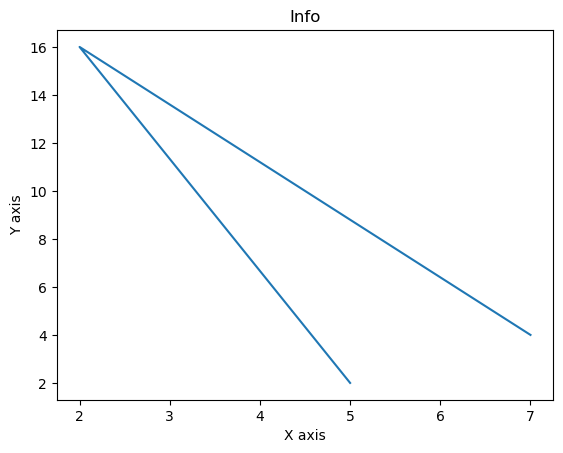

In [30]:
x = [5,2,7]
y= [2,16,4]
plt.plot(x,y)
plt.title('Info')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

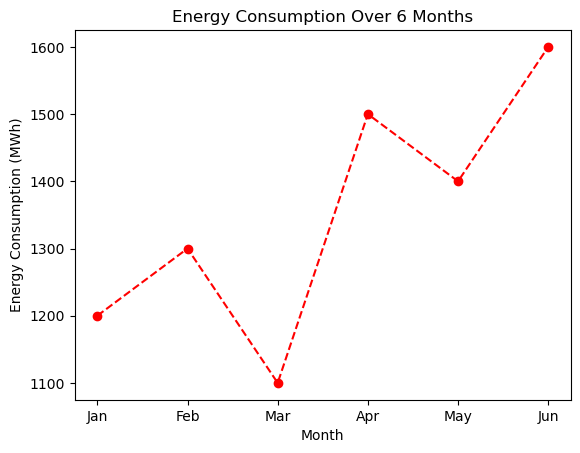

In [31]:
months = ['Jan','Feb','Mar','Apr','May','Jun']
energ_consumption = [1200,1300,1100,1500,1400,1600]
plt.plot(months,energ_consumption,marker='o',color = 'r',linestyle= '--')
plt.title('Energy Consumption Over 6 Months')
plt.xlabel('Month')
plt.ylabel('Energy Consumption (MWh)')
plt.show()

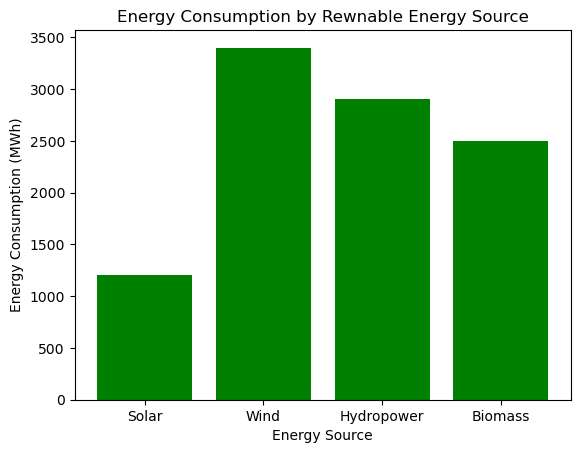

In [32]:
energy_sources=['Solar','Wind','Hydropower','Biomass']
energy_consumption=[1200,3400,2900,2500]
plt.bar(energy_sources,energy_consumption,color='green')
plt.title('Energy Consumption by Rewnable Energy Source')
plt.xlabel('Energy Source')
plt.ylabel('Energy Consumption (MWh)')
plt.show()

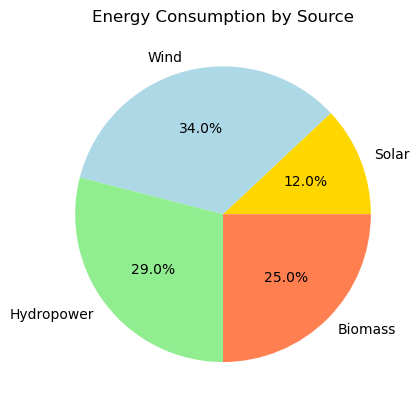

In [33]:
plt.pie(energy_consumption,labels=energy_sources,autopct='%1.1f%%',colors=['gold','lightblue','lightgreen','coral'])
plt.title('Energy Consumption by Source')
plt.show()

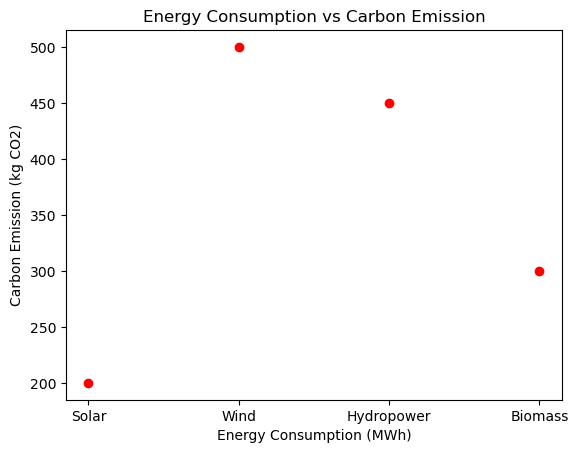

In [34]:
carbon_emission=[200,500,450,300]
plt.scatter(energy_sources,carbon_emission,color='red')
plt.title('Energy Consumption vs Carbon Emission')
plt.xlabel('Energy Consumption (MWh)')
plt.ylabel('Carbon Emission (kg CO2)')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

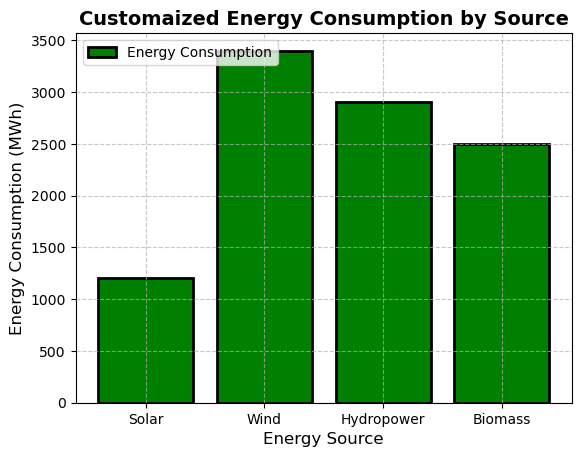

In [35]:
plt.bar(energy_sources,energy_consumption,color='green',edgecolor='black',linewidth=2)
plt.title('Customaized Energy Consumption by Source',fontsize=14,fontweight='bold')
plt.xlabel('Energy Source',fontsize=12)
plt.ylabel('Energy Consumption (MWh)',fontsize=12)
plt.grid(True,linestyle='--',alpha=0.7)
plt.legend(['Energy Consumption'],loc='upper left')
plt.show

## SeaBorn

In [37]:
import seaborn as sns

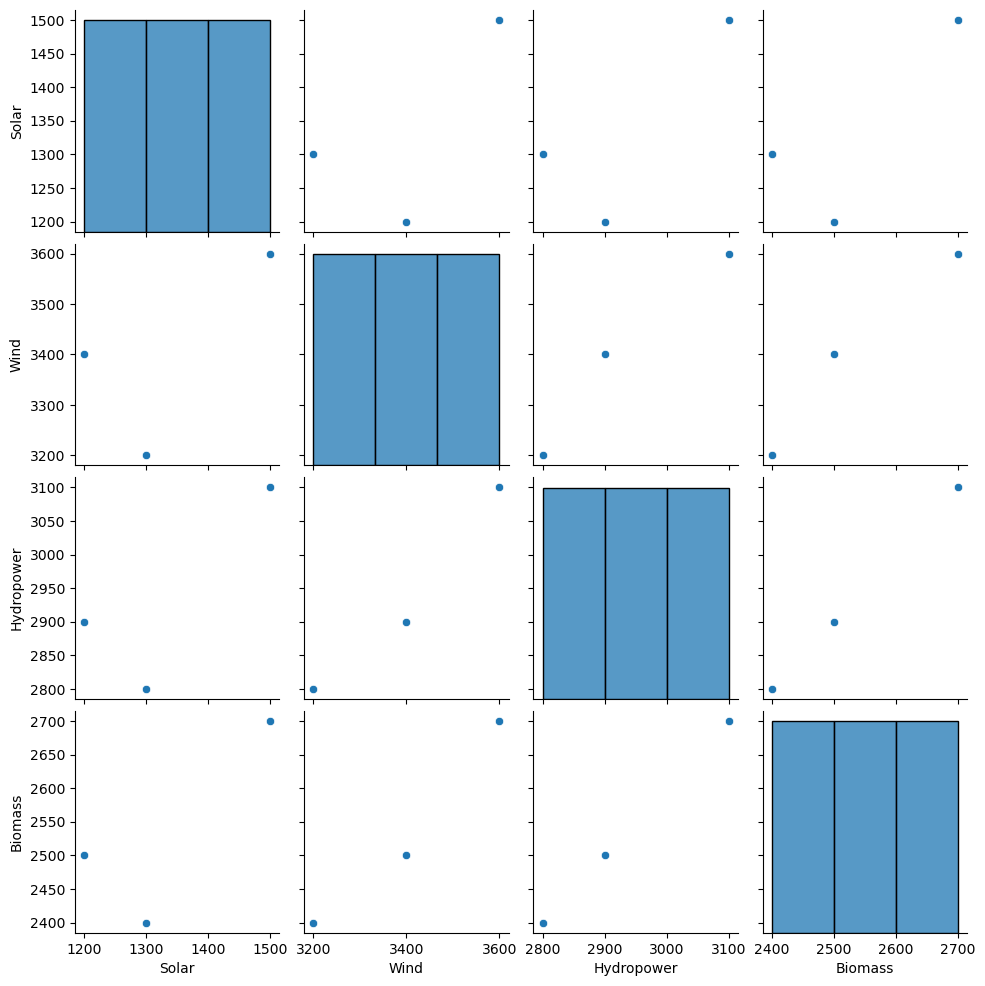

In [38]:
data={
    'Solar':[1200,1500,1300],
    'Wind':[3400,3600,3200],
    'Hydropower':[2900,3100,2800],
    'Biomass':[2500,2700,2400]
}
df=pd.DataFrame(data)
sns.pairplot(df)
plt.show()

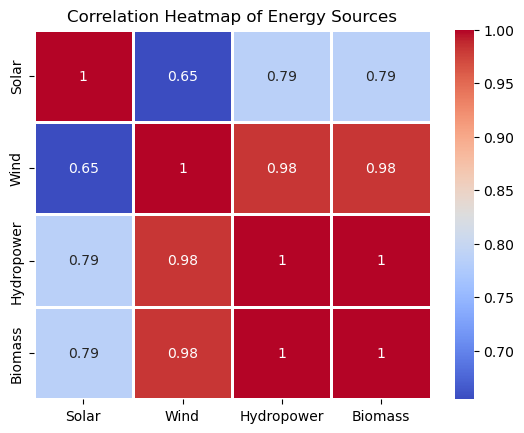

In [39]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',linewidth=1)
plt.title('Correlation Heatmap of Energy Sources')
plt.show()

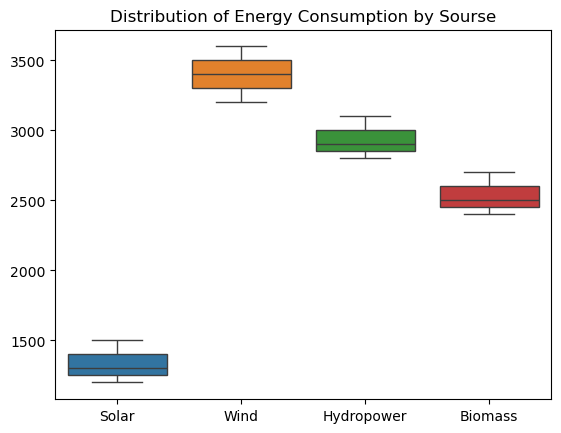

In [40]:
sns.boxplot(data=df)
plt.title('Distribution of Energy Consumption by Sourse')
plt.show()

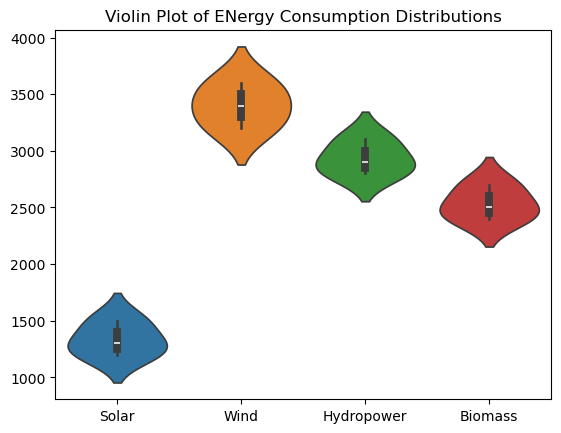

In [41]:
sns.violinplot(data=df)
plt.title("Violin Plot of ENergy Consumption Distributions")
plt.show()

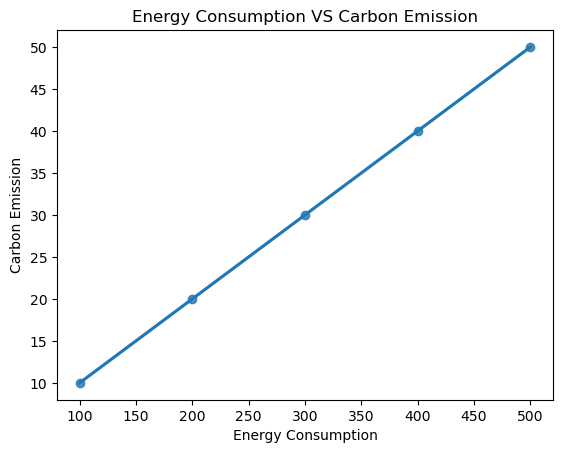

In [80]:
energy_values=[100,200,300,400,500]
carbon_emission1=[10,20,30,40,50]
df_reg=pd.DataFrame({'Energy Consumption':energy_values,'Carbon Emission':carbon_emission1})
sns.regplot(x='Energy Consumption',y='Carbon Emission',data=df_reg)
plt.title('Energy Consumption VS Carbon Emission')
plt.ylabel("Energy Consumption")
plt.ylabel("Carbon Emission")
plt.show()

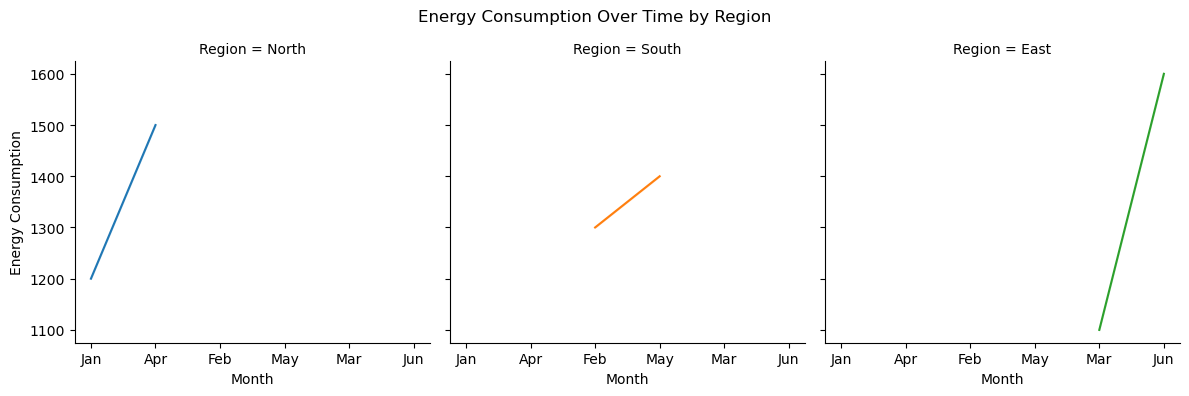

In [86]:
months = ['Jan','Feb','Mar','Apr','May','Jun']
df_facet = pd.DataFrame({
    'Month':months*3,
    'Energy Consumption':[1200,1300,1100,1500,1400,1600]*3,
    'Region':['North','South','East']*6
})
g=sns.FacetGrid(df_facet,col='Region',hue='Region',height=4,aspect=1)
g.map(sns.lineplot,'Month','Energy Consumption')
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Energy Consumption Over Time by Region')
plt.show()